# Gaia GSP-Phot Temperature Validation

This notebook validates our predicted temperatures against Gaia GSP-Phot temperatures and examines the HR diagram to check for systematic biases.

**Goals:**
- Compare predicted temperature distribution with Gaia GSP-Phot temperatures
- Plot HR diagrams for both temperature sources
- Identify any systematic biases or discrepancies


## Setup and Imports

Import required libraries and utilities from the project modules.


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import utilities
from src.notebook_utils import (
    save_figure,
    MISSING_VALUE,
    RANDOM_STATE
)
from src.config import get_config

# Configuration
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

config = get_config()
print("✓ Setup complete")


✓ Setup complete


## Load Data

Load the catalog with predicted temperatures and Gaia GSP-Phot temperatures for comparison.


In [3]:
# Load training data with Gaia GSP-Phot temperatures
gaia_data = pd.read_parquet(config.get_dataset_path('ml_training_clean', 'processed'))
print(f"Loaded {len(gaia_data):,} objects with Gaia GSP-Phot temperatures")
print(f"Columns: {list(gaia_data.columns)}")

# Load full catalog with predicted temperatures
pred_data = pd.read_parquet(config.get_dataset_path('eb_full_catalog_temps', 'processed'))
print(f"\nLoaded {len(pred_data):,} objects with predicted temperatures")
print(f"Columns: {list(pred_data.columns)}")

# Summary statistics
print("\n" + "="*60)
print("GAIA GSP-PHOT TEMPERATURES (Training Data)")
print("="*60)
print(f"Count: {gaia_data['teff_gspphot'].notna().sum():,}")
print(f"Mean: {gaia_data['teff_gspphot'].mean():.1f} K")
print(f"Median: {gaia_data['teff_gspphot'].median():.1f} K")
print(f"Std: {gaia_data['teff_gspphot'].std():.1f} K")

print("\n" + "="*60)
print("PREDICTED TEMPERATURES (Full Catalog)")
print("="*60)
print(f"Count: {pred_data['teff_predicted'].notna().sum():,}")
print(f"Mean: {pred_data['teff_predicted'].mean():.1f} K")
print(f"Median: {pred_data['teff_predicted'].median():.1f} K")
print(f"Std: {pred_data['teff_predicted'].std():.1f} K")

gaia_data.head()


Loaded 705,998 objects with Gaia GSP-Phot temperatures
Columns: ['original_ext_source_id', 'g_r_color', 'r_i_color', 'i_z_color', 'B_V_color', 'gPSFMag', 'teff_gspphot']

Loaded 429,500 objects with predicted temperatures
Columns: ['source_id', 'ra', 'dec', 'phot_g_mean_mag', 'bp_rp', 'g_r_color', 'r_i_color', 'i_z_color', 'B_V_color', 'gPSFMag', 'teff_predicted', 'prediction_method', 'model_id']

GAIA GSP-PHOT TEMPERATURES (Training Data)
Count: 705,998
Mean: 5317.2 K
Median: 4967.0 K
Std: 1422.8 K

PREDICTED TEMPERATURES (Full Catalog)
Count: 429,500
Mean: 9328.7 K
Median: 9172.8 K
Std: 1057.2 K


,original_ext_source_id,g_r_color,r_i_color,i_z_color,B_V_color,gPSFMag,teff_gspphot
0,109270450082003814,0.357201,0.074599,0.171000,0.549409,15.891400,6317.194336
1,109030455555466575,0.554600,0.332001,0.097198,0.725370,18.137400,4596.814453
2,109510460340003115,0.818900,0.160200,0.381200,0.960968,14.457200,4162.139160
3,109990456293919491,0.091299,-0.014299,-0.005001,0.312384,18.145599,6881.932129
4,110080468746484553,0.143900,-0.050500,0.011700,0.359272,15.043400,6964.344727


## Temperature Distribution Comparison

Compare the distributions of Gaia GSP-Phot temperatures (training data) vs. predicted temperatures (full catalog) to check for systematic differences or biases.


/var/folders/dh/bbtpjwmd2sx_tz124bn85xrr0000gn/T/ipykernel_87407/397773463.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(box_data, labels=['Gaia GSP-Phot', 'Predicted'], patch_artist=True)


✓ Saved figure: reports/figures/validation/temperature_distribution_comparison.png


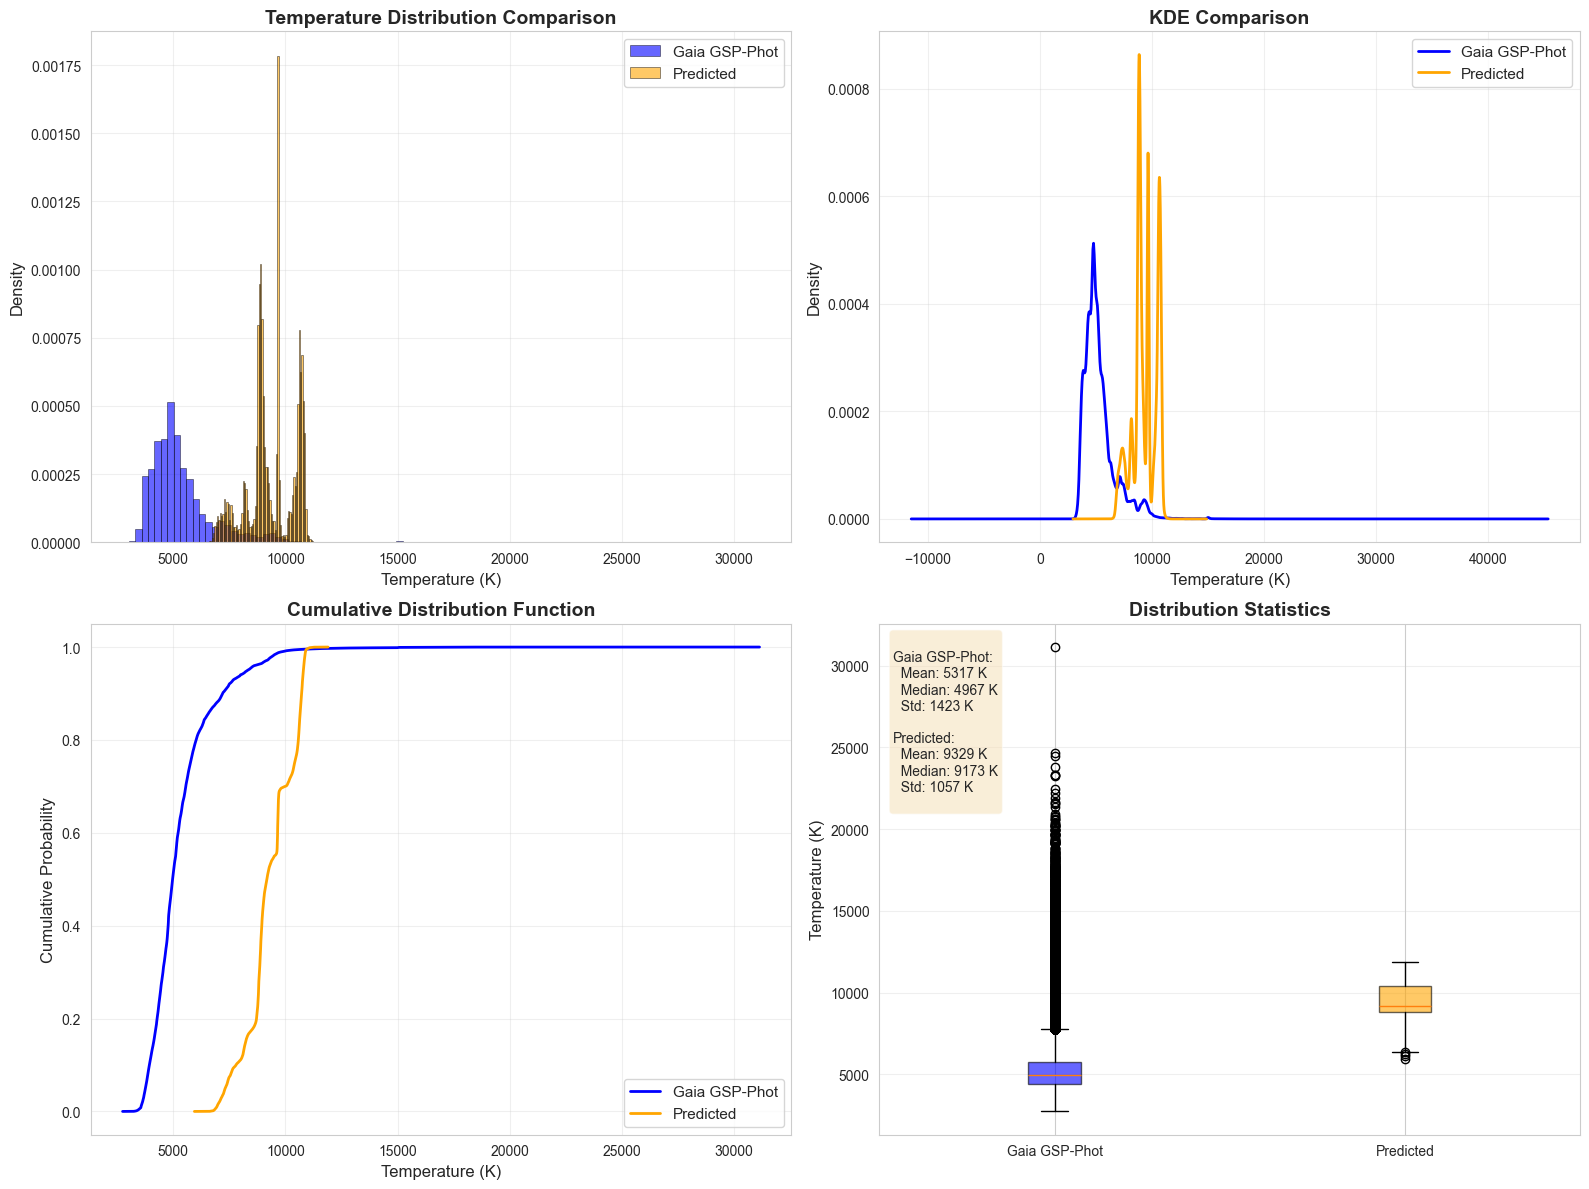

✓ Distribution comparison complete


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overlaid histograms
ax1 = axes[0, 0]
ax1.hist(gaia_data['teff_gspphot'].dropna(), bins=100, alpha=0.6, label='Gaia GSP-Phot', 
         color='blue', density=True, edgecolor='black', linewidth=0.5)
ax1.hist(pred_data['teff_predicted'].dropna(), bins=100, alpha=0.6, label='Predicted', 
         color='orange', density=True, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Temperature (K)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Temperature Distribution Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# 2. KDE plots
ax2 = axes[0, 1]
gaia_data['teff_gspphot'].dropna().plot.kde(ax=ax2, label='Gaia GSP-Phot', 
                                             color='blue', linewidth=2)
pred_data['teff_predicted'].dropna().plot.kde(ax=ax2, label='Predicted', 
                                               color='orange', linewidth=2)
ax2.set_xlabel('Temperature (K)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('KDE Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# 3. Cumulative distribution
ax3 = axes[1, 0]
gaia_sorted = np.sort(gaia_data['teff_gspphot'].dropna())
pred_sorted = np.sort(pred_data['teff_predicted'].dropna())
ax3.plot(gaia_sorted, np.linspace(0, 1, len(gaia_sorted)), label='Gaia GSP-Phot', 
         color='blue', linewidth=2)
ax3.plot(pred_sorted, np.linspace(0, 1, len(pred_sorted)), label='Predicted', 
         color='orange', linewidth=2)
ax3.set_xlabel('Temperature (K)', fontsize=12)
ax3.set_ylabel('Cumulative Probability', fontsize=12)
ax3.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(alpha=0.3)

# 4. Box plots
ax4 = axes[1, 1]
box_data = [gaia_data['teff_gspphot'].dropna(), pred_data['teff_predicted'].dropna()]
bp = ax4.boxplot(box_data, labels=['Gaia GSP-Phot', 'Predicted'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('orange')
bp['boxes'][1].set_alpha(0.6)
ax4.set_ylabel('Temperature (K)', fontsize=12)
ax4.set_title('Distribution Statistics', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3, axis='y')

# Add statistics text
stats_text = f"""
Gaia GSP-Phot:
  Mean: {gaia_data['teff_gspphot'].mean():.0f} K
  Median: {gaia_data['teff_gspphot'].median():.0f} K
  Std: {gaia_data['teff_gspphot'].std():.0f} K

Predicted:
  Mean: {pred_data['teff_predicted'].mean():.0f} K
  Median: {pred_data['teff_predicted'].median():.0f} K
  Std: {pred_data['teff_predicted'].std():.0f} K
"""
ax4.text(0.02, 0.98, stats_text, transform=ax4.transAxes, 
         fontsize=10, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
save_figure(fig, 'temperature_distribution_comparison.png', subdir='validation')
plt.show()

print("✓ Distribution comparison complete")


## HR Diagram Comparison

Compare HR diagrams for both datasets to identify any systematic biases or differences in the distribution of stars in color-magnitude space.


✓ Saved figure: reports/figures/validation/hr_diagram_comparison.png


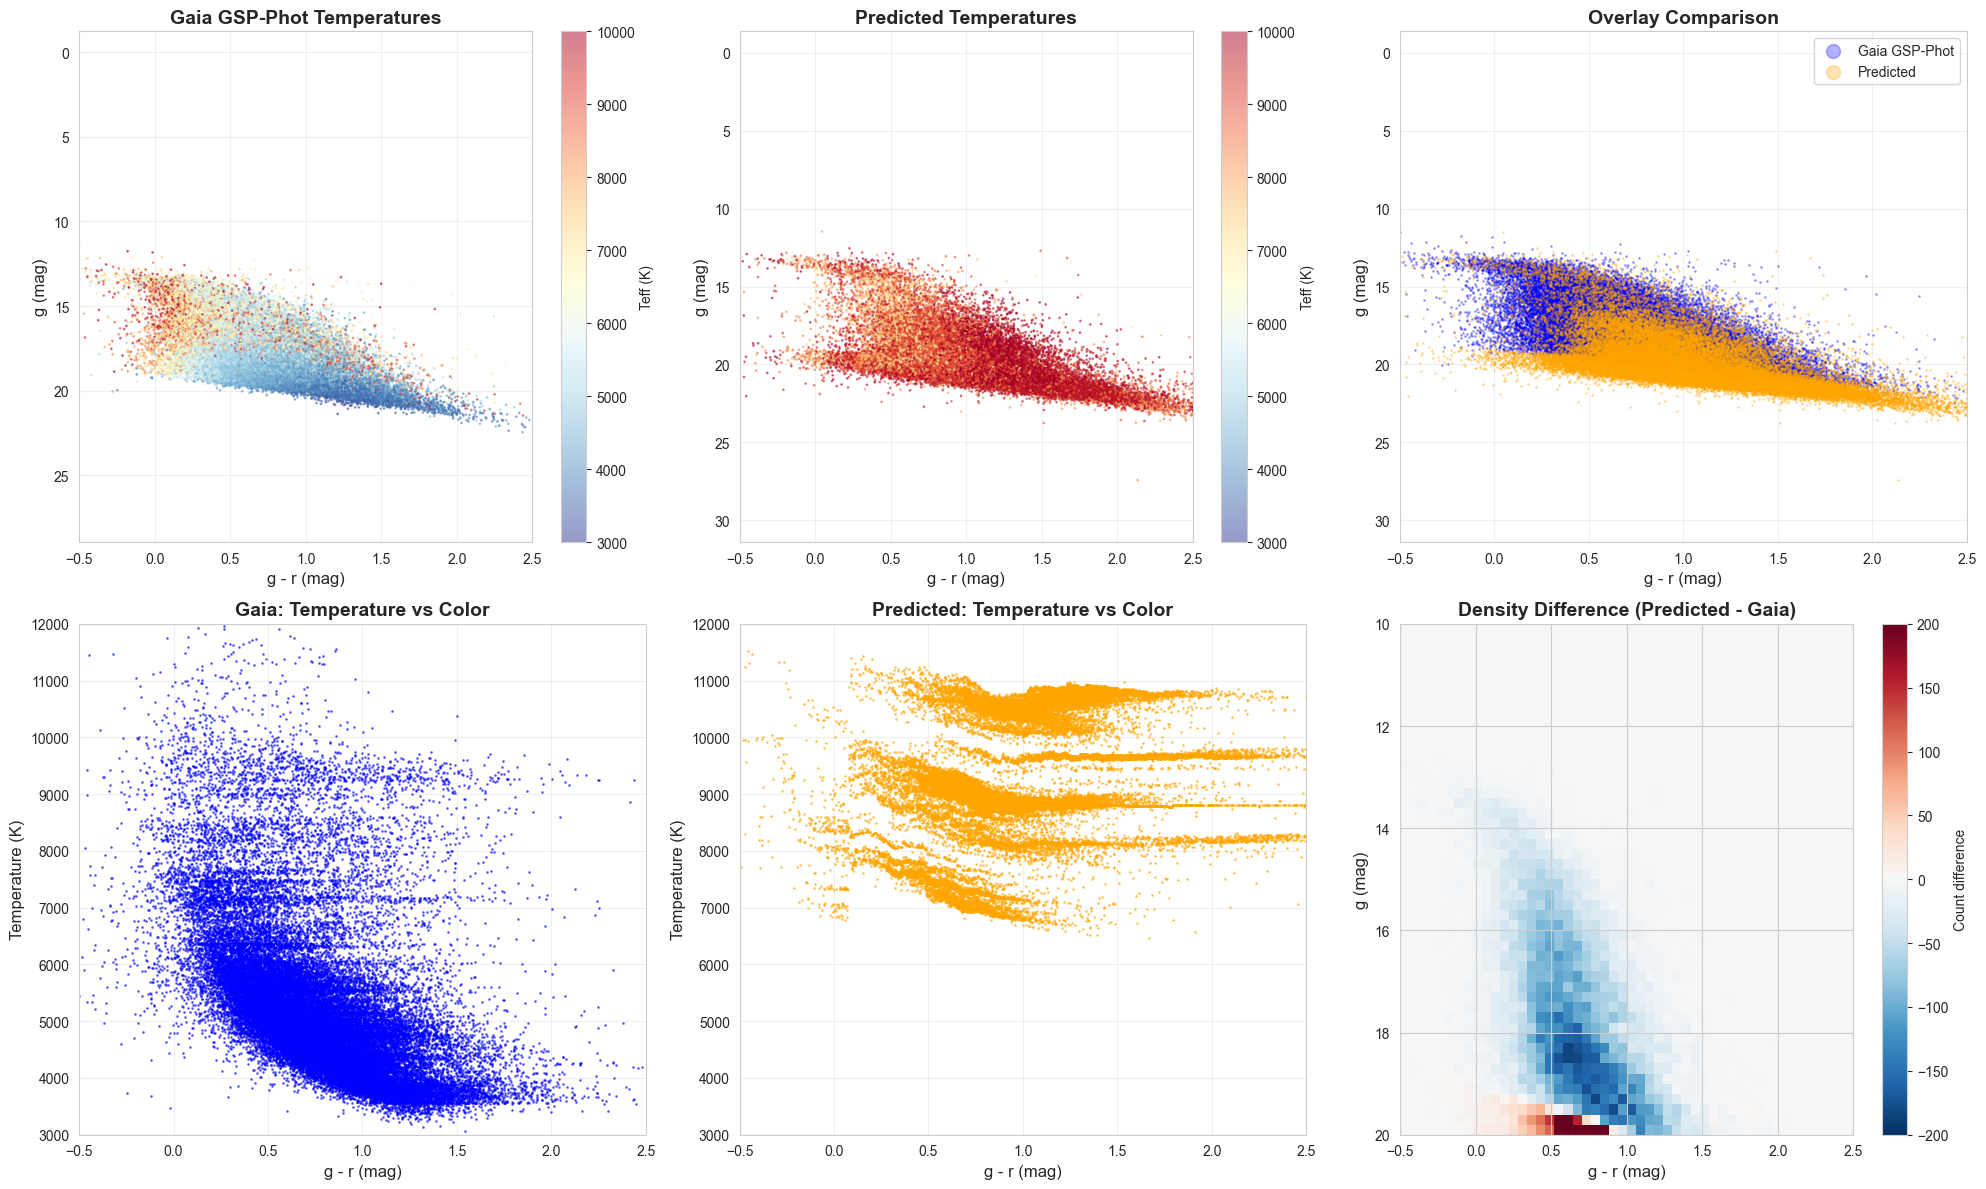

✓ HR diagram comparison complete


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Sample data for plotting (to avoid overplotting)
sample_size = 50000
gaia_sample = gaia_data.sample(n=min(sample_size, len(gaia_data)), random_state=RANDOM_STATE)
pred_sample = pred_data.sample(n=min(sample_size, len(pred_data)), random_state=RANDOM_STATE)

# 1. Gaia GSP-Phot: g-r vs g magnitude, colored by temperature
ax1 = axes[0, 0]
scatter1 = ax1.scatter(gaia_sample['g_r_color'], gaia_sample['gPSFMag'], 
                       c=gaia_sample['teff_gspphot'], cmap='RdYlBu_r', 
                       s=1, alpha=0.5, vmin=3000, vmax=10000)
ax1.set_xlabel('g - r (mag)', fontsize=12)
ax1.set_ylabel('g (mag)', fontsize=12)
ax1.set_title('Gaia GSP-Phot Temperatures', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.set_xlim(-0.5, 2.5)
ax1.grid(alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Teff (K)')

# 2. Predicted: g-r vs g magnitude, colored by temperature
ax2 = axes[0, 1]
scatter2 = ax2.scatter(pred_sample['g_r_color'], pred_sample['gPSFMag'], 
                       c=pred_sample['teff_predicted'], cmap='RdYlBu_r', 
                       s=1, alpha=0.5, vmin=3000, vmax=10000)
ax2.set_xlabel('g - r (mag)', fontsize=12)
ax2.set_ylabel('g (mag)', fontsize=12)
ax2.set_title('Predicted Temperatures', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.set_xlim(-0.5, 2.5)
ax2.grid(alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Teff (K)')

# 3. Overlay comparison
ax3 = axes[0, 2]
ax3.scatter(gaia_sample['g_r_color'], gaia_sample['gPSFMag'], 
            s=1, alpha=0.3, color='blue', label='Gaia GSP-Phot')
ax3.scatter(pred_sample['g_r_color'], pred_sample['gPSFMag'], 
            s=1, alpha=0.3, color='orange', label='Predicted')
ax3.set_xlabel('g - r (mag)', fontsize=12)
ax3.set_ylabel('g (mag)', fontsize=12)
ax3.set_title('Overlay Comparison', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
ax3.set_xlim(-0.5, 2.5)
ax3.legend(fontsize=10, markerscale=10)
ax3.grid(alpha=0.3)

# 4. Temperature vs g-r color (Gaia)
ax4 = axes[1, 0]
ax4.scatter(gaia_sample['g_r_color'], gaia_sample['teff_gspphot'], 
            s=1, alpha=0.5, color='blue')
ax4.set_xlabel('g - r (mag)', fontsize=12)
ax4.set_ylabel('Temperature (K)', fontsize=12)
ax4.set_title('Gaia: Temperature vs Color', fontsize=14, fontweight='bold')
ax4.set_xlim(-0.5, 2.5)
ax4.set_ylim(3000, 12000)
ax4.grid(alpha=0.3)

# 5. Temperature vs g-r color (Predicted)
ax5 = axes[1, 1]
ax5.scatter(pred_sample['g_r_color'], pred_sample['teff_predicted'], 
            s=1, alpha=0.5, color='orange')
ax5.set_xlabel('g - r (mag)', fontsize=12)
ax5.set_ylabel('Temperature (K)', fontsize=12)
ax5.set_title('Predicted: Temperature vs Color', fontsize=14, fontweight='bold')
ax5.set_xlim(-0.5, 2.5)
ax5.set_ylim(3000, 12000)
ax5.grid(alpha=0.3)

# 6. 2D histogram comparison
ax6 = axes[1, 2]
h_gaia, xedges, yedges = np.histogram2d(
    gaia_sample['g_r_color'].dropna(), 
    gaia_sample['gPSFMag'].dropna(), 
    bins=50, range=[[-0.5, 2.5], [10, 20]]
)
h_pred, _, _ = np.histogram2d(
    pred_sample['g_r_color'].dropna(), 
    pred_sample['gPSFMag'].dropna(), 
    bins=50, range=[[-0.5, 2.5], [10, 20]]
)
# Calculate difference
diff = h_pred - h_gaia
im = ax6.imshow(diff.T, origin='lower', aspect='auto', 
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                cmap='RdBu_r', vmin=-200, vmax=200)
ax6.set_xlabel('g - r (mag)', fontsize=12)
ax6.set_ylabel('g (mag)', fontsize=12)
ax6.set_title('Density Difference (Predicted - Gaia)', fontsize=14, fontweight='bold')
ax6.invert_yaxis()
plt.colorbar(im, ax=ax6, label='Count difference')

plt.tight_layout()
save_figure(fig, 'hr_diagram_comparison.png', subdir='validation')
plt.show()

print("✓ HR diagram comparison complete")
